In [1]:
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn  # Import neural network module
import torch.optim as optim  # Import optimization module
import src
from src.data.synthetic_data import SyntheticDataGenerator
from src.data.dataset import KineticDataset, Normalize
from src.data.data_loader import get_data_loaders, load_data
from src.models.crnn import CRNN
from src.models.loss_fn import RangeNormalizedMAE, RangeNormalizedMSE
import json
from src.models.train_tune import train
# For one step reaction
y0 = {
    'S_1' : (10, 100),
    'S_2' : (10, 100),
    'S_3' : (0, 0),
    'S_4' : (0, 0),
    'S_out' : (0, 0),
}
ks = [2e5*1e-9, 1e-3]  # M^-1 s^-1 converted to nM^-1 s^-1
time_hours = 3 #hours
t_end = time_hours * 3600  # seconds
E_bounds = (-np.inf, np.inf)  # No bounds on enzyme concentration


data_gen = SyntheticDataGenerator(
    mechanism='one_step_1latent',
    reaction_rates=ks,
    initial_concentration_ranges=y0,
    noise_level=0,
    t_end=t_end,
    n_timepoints = t_end//30,  # every 30 seconds
    seed=42,
    E_bounds=E_bounds,
)

batch_size = 50
batch = data_gen.generate_batch(batch_size)
norm = Normalize(max_concentration=torch.max(batch["c0"]))

ds = KineticDataset(batch, transform=norm)

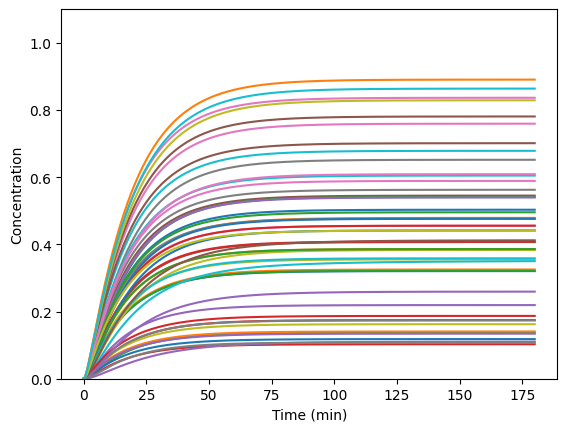

c0: [0.80938655 0.50296086 0.         0.         0.        ], E: 36.96332881979388
c0: [0.68831265 0.47861725 0.         0.         0.        ], E: 35.22197594633701
c0: [0.45040667 0.13719381 0.         0.         0.        ], E: 25.57843883689631
c0: [0.43941447 0.10257221 0.         0.         0.        ], E: 24.76666075688982
c0: [0.60404056 0.21915598 0.         0.         0.        ], E: 29.129128075148742
c0: [0.40670255 0.7301741  0.         0.         0.        ], E: 34.26343169342796
c0: [0.45513517 0.983286   0.         0.         0.        ], E: 36.84741945087386
c0: [0.95595795 0.5623373  0.         0.         0.        ], E: 39.217098026766465
c0: [0.35519361 0.74954784 0.         0.         0.        ], E: 33.374318893627446
c0: [0.6783054  0.90628266 0.         0.         0.        ], E: 41.286945851457325
c0: [0.320317 0.956722 0.       0.       0.      ], E: 33.581572705437964
c0: [0.32515216 0.93517095 0.         0.         0.        ], E: 33.67056828815213
c0: [0.32

In [2]:
# Visualize kinetics for each sample on a single plot
t = ds.get_t().numpy()
for i in range(batch_size):
    sample = ds[i]
    y = sample['y'].numpy()
    
    plt.plot(t/60, y, label=f'Sample {i}')
plt.xlabel('Time (min)')
plt.ylabel('Concentration')
plt.ylim(0, 1.1)
plt.show()

for d in ds:
    c0 = d['c0']
    E = data_gen._E_from_fim(data_gen._SVD(data_gen._compute_fim_output(c0, summed = True)))
    print(f"c0: {c0.numpy()}, E: {E}")

In [ ]:
#hyperparameters
config = json.load(open('config.json'))
config["n_train"] = 25
config["num_reactions"] = 2
config["lr"] = 0.01
config["batch_size"] = 5

### Known species experiment

In [15]:
train_loss, val_loss, model, test_loader = train(config, ds, report = 10)

Epoch 0: Train Loss: 0.349646, Val Loss: 0.608083
Epoch 10: Train Loss: 0.337169, Val Loss: 0.606908
Epoch 20: Train Loss: 0.347191, Val Loss: 0.605336
Epoch 30: Train Loss: 0.337857, Val Loss: 0.603584
Epoch 40: Train Loss: 0.337447, Val Loss: 0.601468
Epoch 50: Train Loss: 0.343654, Val Loss: 0.598835
Epoch 60: Train Loss: 0.330531, Val Loss: 0.595961
Epoch 70: Train Loss: 0.329881, Val Loss: 0.592227


KeyboardInterrupt: 

In [5]:
params = (model.nu().detach().cpu().numpy(), model.log_k.detach().cpu().numpy())
norm_value = ds.transform.max_c0.item()
k = np.exp(params[1])  # in M^-1 s^-1
k_normed = np.zeros(k.shape)
nu = params[0]
for i_col in range(nu.shape[1]):
    react_weights = [v for v in nu[:, i_col] if v > 0]
    order = np.sum(react_weights)
    k_normed[i_col] = k[i_col] * ((1e9/norm_value) **(order - 1))
plt.plot(train_loss, color = "blue")
plt.plot(val_loss, color = "orange")
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned Reaction stoichiometry')
print(-1*nu)  # neg
print('Learned reaction rates:', k_normed)  # in M^-1 s^-1

NameError: name 'model' is not defined

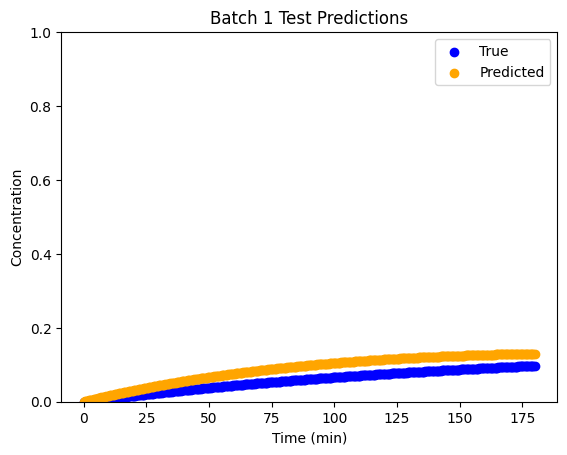

In [31]:
# Plot test predictions over test loader
model.eval()
t_train = ds.get_t()
out_ind = ds.get_output_index()  # index of output species
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"]
        y_true = batch["y"]

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.ylim(0,1)
        plt.legend()
        plt.show()

### all possible species with single atom counts

In [ ]:
# global constants pulled from the *base dataset*
A_control = np.array([
    [1, 0, 1, 1, 0, 0, 1],  # Atom A
    [0, 1, 1, 0, 1, 0, 1],  # Atom B
    [0, 1, 1, 1, 0, 1, 0],  # Atom C
])       # for scipy.null_spa


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(A_control, num_reactions).to(device)

# Loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-8)

t_train = base_ds.get_t().to(device).float()

loss_hist = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        c0 = batch["c0"].to(device).float()
        #if there are not enough c0 for the control A add zeros
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device).float()

        optimizer.zero_grad(set_to_none=True)

        y_full = model(t_train, c0)              # (B, T, N)
        y_pred = y_full[:, :, out_ind] # (B, T, 1)
        loss_value = loss_fn(y_pred, y_true) + lambda_l1 * model.nu().abs().sum()
        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.6f}")
        #print(f"    k: {1e9*np.exp(model.log_k.detach().cpu().numpy())}")
        #print(f"    Sum stoich:\n{np.sum(np.abs((model.nu().detach().cpu().numpy())))}\n")

# print final loss, plot history, and report paramaters
print(f"Final training loss: {loss_hist[-1]:.6f}")

Epoch 1/500 | loss 0.668601
Epoch 11/500 | loss 0.401095
Epoch 21/500 | loss 0.232508
Epoch 31/500 | loss 0.127210
Epoch 41/500 | loss 0.060366
Epoch 51/500 | loss 0.183247
Epoch 61/500 | loss 0.050848
Epoch 71/500 | loss 0.123800
Epoch 81/500 | loss 0.157508
Epoch 91/500 | loss 0.065769
Epoch 101/500 | loss 0.073770
Epoch 111/500 | loss 0.041235
Epoch 121/500 | loss 0.039651
Epoch 131/500 | loss 0.097349
Epoch 141/500 | loss 0.033663
Epoch 151/500 | loss 0.075361
Epoch 161/500 | loss 0.070456
Epoch 171/500 | loss 0.029652
Epoch 181/500 | loss 0.031166
Epoch 191/500 | loss 0.159013
Epoch 201/500 | loss 0.179381
Epoch 211/500 | loss 0.050527
Epoch 221/500 | loss 0.051636
Epoch 231/500 | loss 0.045158
Epoch 241/500 | loss 0.045231
Epoch 251/500 | loss 0.029055
Epoch 261/500 | loss 0.106249
Epoch 271/500 | loss 0.052832
Epoch 281/500 | loss 0.128220
Epoch 291/500 | loss 0.029223
Epoch 301/500 | loss 0.070381
Epoch 311/500 | loss 0.051799
Epoch 321/500 | loss 0.069533
Epoch 331/500 | loss 

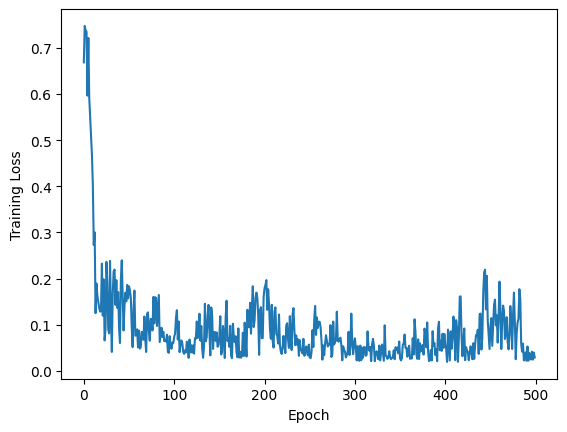

Learned reaction rates: [487248.8]
Reaction stoichiometry
[[-0.69812155]
 [-0.7683414 ]
 [-0.11631817]
 [ 0.6703864 ]
 [ 0.7406064 ]
 [ 0.21427321]
 [ 0.14405325]]


In [ ]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned reaction rates:', np.exp(model.log_k.detach().cpu().numpy())*1e9/norm_value)  # in M^~-1 s^-1
print('Reaction stoichiometry')
print(-1*model.nu().detach().numpy())

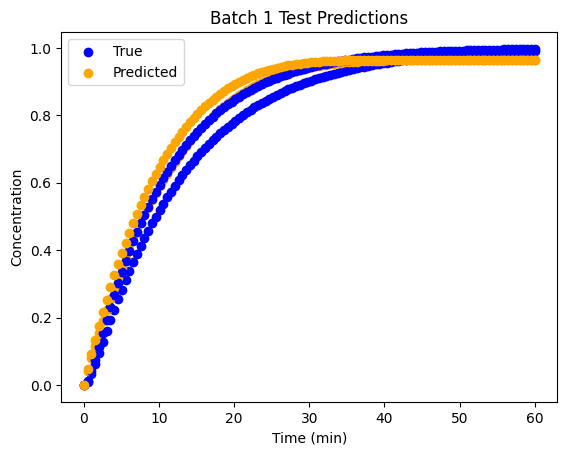

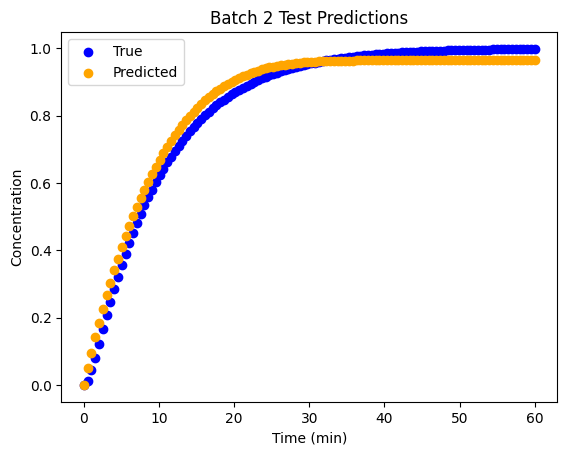

In [ ]:
# Plot test predictions over test loader
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"].to(device)
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device)

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.legend()
        plt.show()